In [7]:
%pip install numpy
%pip install pillow
%pip install matplotlib
%pip install opencv-python
%pip install tifffile 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
from PIL import Image
from typing import List
from itertools import permutations
import matplotlib.pyplot as plt
import tifffile 
from pathlib import Path

In [14]:
base = Path().resolve().parent
carpeta_resultados = base / "Resultados"
ruta_cifrado = carpeta_resultados / "cifrado.tiff"
ruta_meta = carpeta_resultados / "cifrado_meta.txt"

In [15]:
def generar_matrices_4x4():    
    sigma_x = np.array([[0, 1],
                        [1, 0]], dtype=complex)

    sigma_y = np.array([[0, -1j],
                        [1j,  0]], dtype=complex)

    sigma_z = np.array([[1,  0],
                        [0, -1]], dtype=complex)

    I = np.eye(2, dtype=complex)

    ops = [I, sigma_x, sigma_y, sigma_z]

    matrices_4x4 = []
    for M1, M2, M3, M4 in permutations(ops, 4):
        M = np.block([[M1, M2],
                      [M3, M4]])
        matrices_4x4.append(M)

    return matrices_4x4


def matrices_encriptacion(llave: List[int], matrices_rotacion):
    matrices_encript = []
    for item in llave:
        matrices_encript.append(matrices_rotacion[item % 24])
    return matrices_encript

In [16]:
# Funcion meramente cosmetica, basicamente para poder ver las imagenes con sus colores una vez obtenemos el RGB
def visualizar_canal_color(canal_img: Image.Image, color: str) -> Image.Image:
    color = color.upper()
    if color not in ["R", "G", "B"]:
        raise ValueError()

    arr = np.array(canal_img)
    zeros = np.zeros_like(arr)

    if color == "R":
        rgb = np.stack([arr, zeros, zeros], axis=2)
    elif color == "G":
        rgb = np.stack([zeros, arr, zeros], axis=2)
    else:
        rgb = np.stack([zeros, zeros, arr], axis=2)

    return Image.fromarray(rgb, mode="RGB")

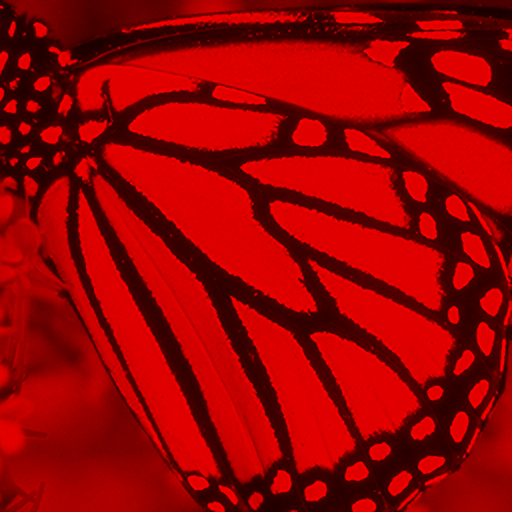

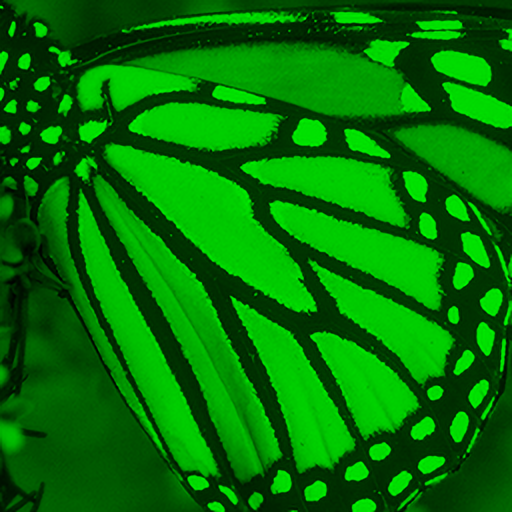

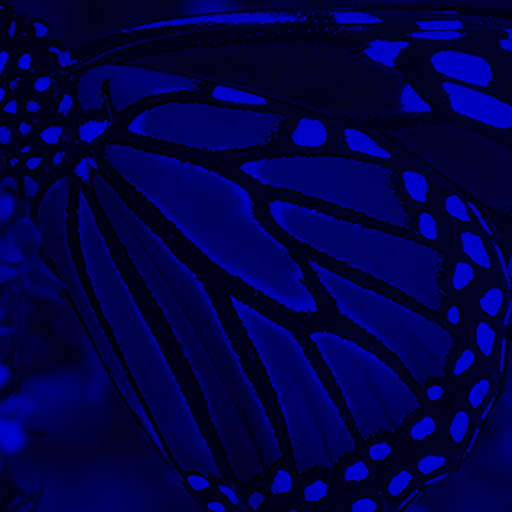

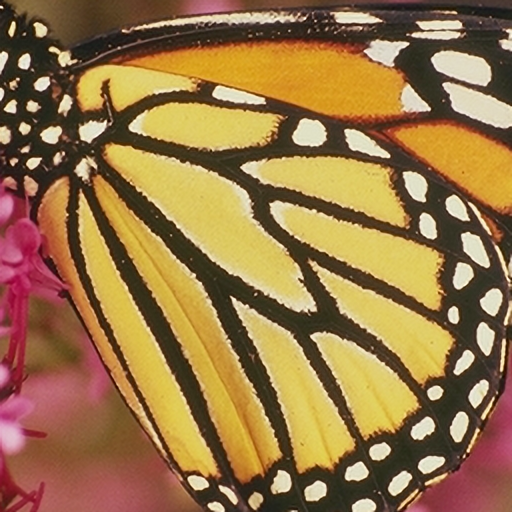

In [13]:
# Leer llave del meta.txt
with open(str(ruta_meta), "r") as f:
    linea = f.readline()
key = list(map(int, linea.split("=")[1].strip()[1:-1].split(",")))

# Leer tiff y obtener shape directamente
cifrado_stack = tifffile.imread(str(ruta_cifrado)).astype(np.float64)
h_orig, w_orig = cifrado_stack.shape[1], cifrado_stack.shape[2]

# Reconstruir canales complejos
c_r_2d = cifrado_stack[0] + 1j * cifrado_stack[3]
c_g_2d = cifrado_stack[1] + 1j * cifrado_stack[4]
c_b_2d = cifrado_stack[2] + 1j * cifrado_stack[5]

# Convertir a bloques (4, N)
def imagen_a_bloques_complejo(canal_2d):
    arr = canal_2d.flatten()
    pad = (4 - len(arr) % 4) % 4
    if pad:
        arr = np.concatenate([arr, np.zeros(pad, dtype=complex)])
    return arr.reshape(4, -1)

c_r_b = imagen_a_bloques_complejo(c_r_2d)
c_g_b = imagen_a_bloques_complejo(c_g_2d)
c_b_b = imagen_a_bloques_complejo(c_b_2d)

# Regenerar matrices con la llave del meta.txt
matrices_rotadas = generar_matrices_4x4()
matrices_cifrado = matrices_encriptacion(key, matrices_rotacion=matrices_rotadas)

# Descifrar
def descifrar_canal(canal_bloques, matrices):
    resultado = canal_bloques.astype(complex)
    for Mi in reversed(matrices):
        resultado = np.linalg.inv(Mi) @ resultado
    return resultado

r_desc = descifrar_canal(c_r_b, matrices_cifrado)
g_desc = descifrar_canal(c_g_b, matrices_cifrado)
b_desc = descifrar_canal(c_b_b, matrices_cifrado)

# Reconstruir canales
def reconstruir_canal(canal_desc, h, w):
    arr = canal_desc.real.flatten()[:h * w]
    return np.clip(np.round(arr), 0, 255).astype(np.uint8).reshape(h, w)

R_rec = reconstruir_canal(r_desc, h_orig, w_orig)
G_rec = reconstruir_canal(g_desc, h_orig, w_orig)
B_rec = reconstruir_canal(b_desc, h_orig, w_orig)

# Visualizar
display(visualizar_canal_color(Image.fromarray(R_rec), 'R'))
display(visualizar_canal_color(Image.fromarray(G_rec), 'G'))
display(visualizar_canal_color(Image.fromarray(B_rec), 'B'))
display(Image.fromarray(np.stack([R_rec, G_rec, B_rec], axis=2), mode="RGB"))